# Transferring of Epithelial cell states from the Gut Cell Atlas (Elementaite, 2021) to Remapped Data Using the `scVI - scANVI` Pipeline

**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 6th January 2025\
**Last modified date:** 22nd January 2025

#### **Objective**

This notebook outlines the process for transferring epithelial cell states annotations from the Gut Cell Atlas (Elementaite, 2021) to a series of remapped datasets using the `scVI - scANVI` pipeline. Our goal is to ensure consistent annotation of cell types across studies and to identify cells requiring manual validation.\
We analyze the confidence scores produced by `scANVI` to identify cells with low classification certainty. These cells are flagged for potential manual review and validation to ensure the accuracy of the annotations.\
Finally, we evaluate the performance of the `scVI` and `scANVI` models using `scIB` metrics. This step helps quantify the quality of the integration, classification, and batch correction.

## Import packages

In [1]:
import scvi
import torch
import anndata
import warnings
import numpy as np
import scanpy as sc
import anndata
import pandas as pd
import plotnine as p
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scib_metrics.benchmark import Benchmarker

import json
from datetime import datetime

2025-01-23 10:11:36.522672: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-23 10:11:36.522714: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-23 10:11:36.522741: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-23 10:11:36.924415: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Setup working environment

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [3]:
warnings.simplefilter(action = 'ignore')
scvi.settings.seed = 1712
%config InlineBackend.print_figure_kwargs = {'facecolor' : "w"}
%config InlineBackend.figure_format = 'retina'
torch.set_float32_matmul_precision('medium')

Seed set to 1712


In [4]:
arches_params = dict(
    use_layer_norm = "both",
    use_batch_norm = "none",
    encode_covariates = True,
    dropout_rate = 0.2,
    n_layers = 3,
)

In [5]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

In [6]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

## Upload data

In [7]:
adata = sc.read_h5ad('integration_of_remapped_data/gut_hs_all_datasets_scVI_scANVI_celltypes_AM_23122024_151117_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 402343 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

In [8]:
adata.obs['celltype'] = adata.obs['C_scANVI']

In [9]:
adata = adata[adata.obs['celltype'] == 'Epithelial']

In [10]:
adata.obs['Integrated_05'].value_counts()

Integrated_05
Unknown                  84843
Enterocyte                9780
TA                        7168
Proximal progenitor       4761
Colonocyte                4170
Stem cells                2703
Distal progenitor         1471
Goblet cell               1181
BEST4+ epithelial         1112
BEST2+ Goblet cell         711
Paneth                     340
EECs                       167
Progenitor (NEUROG3+)      153
EC cells (TAC1+)           117
Tuft                       102
M/X cells (MLN/GHRL+)       92
I cells (CCK+)              88
CLDN10+ cells               77
Microfold cell              68
D cells (SST+)              55
K cells (GIP+)              37
L cells (PYY+)              37
EC cells (NPW+)             11
N cells (NTS+)               5
Germ                         3
β cells (INS+)               3
Fetal venous EC              1
Mesoderm 1 (HAND1+)          1
LTi-like NCR- ILC3           1
Name: count, dtype: int64

In [11]:
adata

View of AnnData object with n_obs × n_vars = 119258 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparatio

In [12]:
del adata.obs['_scvi_batch'], adata.obs['_scvi_labels'], adata.obs['C_scANVI'], adata.obs['confidence_score']
del adata.obsm['X_scANVI'], adata.obsm['X_scVI'], adata.obsm['X_pca'], adata.obsm['umap_uncorrected'], adata.obsm['_scvi_extra_categorical_covs']
del adata.obsm['X_umap_qc']

In [13]:
X_is_raw(adata)

True

## Prepare observations

In [14]:
adata.obs['Protocol REF'] = adata.obs['Protocol REF'].cat.add_categories('Unknown')
adata.obs['Protocol REF'] = adata.obs['Protocol REF'].replace(['  '], 'Unknown')

In [15]:
adata.obs['Protocol REF'].value_counts()

Protocol REF
P-MTAB-95162     45759
P-MTAB-101781    40856
P-MTAB-100978    18237
P-MTAB-102913     7672
P-MTAB-100897     5838
Unknown            896
Name: count, dtype: int64

In [16]:
adata.obs['Performer'].value_counts()

Performer
Wellcome Sanger Institute                                                                            46655
University of Michigan DNA Sequencing core                                                           40856
Wellcome Sanger Institute Cellular Generation and Phenotyping teaml, Kylie James, Rasa Elmentaite    18237
University of Michigan Advanced Genomics Core                                                         7672
Rasa Elmentaite, Kylie James                                                                          5838
Name: count, dtype: int64

In [17]:
adata.obs['library_construction'] = adata.obs['library_construction'].astype(str)
adata.obs['LIBRARY_LAYOUT'] = adata.obs['LIBRARY_LAYOUT'].astype(str)
adata.obs['library_construnction_and_layout'] = adata.obs['library_construction'] + '_' + adata.obs['LIBRARY_LAYOUT']
adata.obs['library_construnction_and_layout'].value_counts()

library_construnction_and_layout
10xV2_PAIRED    70730
10xV2_SINGLE    22780
10xV3_SINGLE    18076
10xV3_PAIRED     7672
Name: count, dtype: int64

In [18]:
adata.obs['donor_id'] = adata.obs['donor_id'].cat.add_categories('cell_culture')
adata.obs['donor_id'] = adata.obs['donor_id'].replace(['nan'], 'cell_culture')

+ Delete samples with less than 10 cells

In [19]:
cell_counts = adata.obs['sample_id'].value_counts()
samples_to_remove = cell_counts[cell_counts < 10].index
adata = adata[~adata.obs['sample_id'].isin(samples_to_remove)].copy()

+ Delete not epithelial cell states 

In [20]:
adata.obs['Integrated_05'].value_counts()

Integrated_05
Unknown                  84836
Enterocyte                9773
TA                        7165
Proximal progenitor       4760
Colonocyte                4170
Stem cells                2697
Distal progenitor         1471
Goblet cell               1181
BEST4+ epithelial         1112
BEST2+ Goblet cell         711
Paneth                     340
EECs                       167
Progenitor (NEUROG3+)      153
EC cells (TAC1+)           117
Tuft                       102
M/X cells (MLN/GHRL+)       92
I cells (CCK+)              88
CLDN10+ cells               77
Microfold cell              68
D cells (SST+)              55
K cells (GIP+)              37
L cells (PYY+)              37
EC cells (NPW+)             11
N cells (NTS+)               5
Germ                         3
β cells (INS+)               3
Fetal venous EC              1
Mesoderm 1 (HAND1+)          1
LTi-like NCR- ILC3           1
Name: count, dtype: int64

In [21]:
adata = adata[adata.obs['Integrated_05'] != 'LTi-like NCR- ILC3']
adata = adata[adata.obs['Integrated_05'] != 'Mesoderm 1 (HAND1+)']
adata = adata[adata.obs['Integrated_05'] != 'Fetal venous EC']
adata = adata[adata.obs['Integrated_05'] != 'Germ']

In [22]:
adata.obs['cell_states'] = adata.obs['Integrated_05'].copy()

In [ ]:
relabel_mapping = {
    'EECs': 'EEC',
    'Progenitor (NEUROG3+)': 'EEC',
    'EC cells (TAC1+)': 'EEC',
    'M/X cells (MLN/GHRL+)': 'EEC',
    'I cells (CCK+)': 'EEC',
    'D cells (SST+)': 'EEC',
    'K cells (GIP+)': 'EEC',
    'L cells (PYY+)': 'EEC',
    'EC cells (NPW+)': 'EEC',
    'N cells (NTS+)': 'EEC',
    '\u03b2 cells (INS+)': 'EEC',  # Greek letter beta
    'Goblet cell': 'Goblet cell',
    'BEST2+ Goblet cell': 'Goblet cell'
}

In [23]:
cell_type_column = 'cell_states' 
adata.obs[cell_type_column] = adata.obs[cell_type_column].replace(relabel_mapping)
print(adata.obs[cell_type_column].value_counts())


cell_states
Unknown                84836
Enterocyte              9773
TA                      7165
Proximal progenitor     4760
Colonocyte              4170
Stem cells              2697
Goblet cell             1892
Distal progenitor       1471
BEST4+ epithelial       1112
EEC                      765
Paneth                   340
Tuft                     102
CLDN10+ cells             77
Microfold cell            68
Name: count, dtype: int64


+ Fix issue with Boolean None

In [24]:
nan_summary = adata.obs.isna().sum()

print(nan_summary[nan_summary > 0])

cell_type               46693
time                   111556
qc_cluster              18222
cluster_passed_qc       18222
consensus_fraction      18222
consensus_passed_qc     18222
gestational_age         72587
passage                 72587
batch                   48528
sampling_site          113391
dtype: int64


In [25]:
nan_info = nan_summary[nan_summary > 0].to_frame(name='NaN Count')
nan_info['Data Type'] = adata.obs.dtypes[nan_summary > 0]

print(nan_info)

                     NaN Count Data Type
cell_type                46693  category
time                    111556   float64
qc_cluster               18222  category
cluster_passed_qc        18222   boolean
consensus_fraction       18222   float64
consensus_passed_qc      18222   boolean
gestational_age          72587  category
passage                  72587  category
batch                    48528  category
sampling_site           113391  category


In [26]:
adata.obs['cell_type'] = adata.obs['cell_type'].replace(['  '], 'unsorted')
adata.obs['cell_type'] = adata.obs['cell_type'].replace(['epithelial cell'], 'intestinal epithelial cell')
adata.obs['cell_type'] = adata.obs['cell_type'].cat.remove_unused_categories()
adata.obs['cell_type'] = adata.obs['cell_type'].fillna('unsorted')
adata.obs['cell_type'].value_counts()

cell_type
unsorted                      67978
intestinal epithelial cell    37360
CD45 negative                  8160
CD45 positive                  5730
Name: count, dtype: int64

In [27]:
adata.obs['cluster_passed_qc'] = adata.obs['cluster_passed_qc'].astype(str)
adata.obs['cluster_passed_qc'] = adata.obs['cluster_passed_qc'].fillna('N/A')
adata.obs['consensus_fraction'] = adata.obs['consensus_fraction'].astype(str)
adata.obs['consensus_fraction'] = adata.obs['consensus_fraction'].fillna('N/A')
adata.obs['consensus_passed_qc'] = adata.obs['consensus_passed_qc'].astype(str)
adata.obs['consensus_passed_qc'] = adata.obs['consensus_passed_qc'].fillna('N/A')
adata.obs['qc_cluster'] = adata.obs['qc_cluster'].astype(str)
adata.obs['qc_cluster'] = adata.obs['qc_cluster'].fillna('N/A')

In [28]:
adata.obs['gestational_age'] = adata.obs['gestational_age'].cat.add_categories('N/A - not fetal')
adata.obs['gestational_age'] = adata.obs['gestational_age'].replace(['  '], 'N/A - not fetal')
adata.obs['gestational_age'] = adata.obs['gestational_age'].fillna('N/A - not fetal')
adata.obs['gestational_age'].value_counts()

gestational_age
N/A - not fetal    73483
11.2               10440
11.9                7519
8.4                 6723
12.2                5401
8.5                 5201
9.9                 3068
7.4                 2933
8.7                 1847
8.9                 1413
10.4                1023
8.1                  177
Name: count, dtype: int64

In [29]:
adata.obs['passage'] = adata.obs['passage'].cat.add_categories('N/A')
adata.obs['passage'] = adata.obs['passage'].replace(['  '], 'N/A')
adata.obs['passage'] = adata.obs['passage'].fillna('N/A')
adata.obs['passage'].value_counts()

passage
N/A    104371
1        6723
2        5201
17       2933
Name: count, dtype: int64

In [30]:
adata.obs['batch'] = adata.obs['batch'].cat.add_categories('unknown')
adata.obs['batch'] = adata.obs['batch'].fillna('unknown')

In [31]:
adata.obs['sampling_site'] = adata.obs['sampling_site'].cat.add_categories('unknown')
adata.obs['sampling_site'] = adata.obs['sampling_site'].replace(['  '], 'unknown')
adata.obs['sampling_site'] = adata.obs['sampling_site'].fillna('unknown')
adata.obs['sampling_site'].value_counts()

sampling_site
unknown     114428
middle        1739
terminal      1687
proximal      1374
Name: count, dtype: int64

In [32]:
nan_summary = adata.obs.isna().sum()

print(nan_summary[nan_summary > 0])

time    111556
dtype: int64


+ Delete organoid data

In [33]:
adata.obs['age_group'].value_counts()

age_group
first trimester       48652
second trimester      28929
cell culture model    22529
adult                 18222
child stage             896
Name: count, dtype: int64

In [34]:
adata = adata[~adata.obs['age_group'].isin(['cell culture model'])].copy()

In [35]:
adata_raw = adata.copy()

## Visualize uncorrected dataset

In [36]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['PLA2G2A', 'GUCA2B', 'GUCA2A', 'CLCA1', 'ATP1A1-AS1', 'REG4', 'ITLN1', 'ITLN2', 'PIGR', 'REG1A', 'REG3A', 'FABP1', 'GCG', 'CRYBA2', 'GHRL', 'CCK', 'RBP2', 'SST', 'ENSG00000286848', 'JCHAIN', 'GC', 'RPL34', 'CCDC152', 'ATG10', 'SPINK1', 'FABP6', 'ENSG00000271581', 'MLN', 'ENSG00000287089', 'CLPS', 'AGR2', 'RPL30-AS1', 'RPS6', 'SPINK4', 'RPL12', 'LCN15', 'VIM-AS1', 'ADIRF-AS1', 'SHLD2', 'INS', 'BEST1', 'FTH1', 'TALAM1', 'ENSG00000285513', 'APOA4', 'APOC3', 'APOA1', 'APOA1-AS', 'ENSG00000269968', 'MRPS35-DT', 'LYZ', 'ENSG00000257764', 'NTS', 'TPT1', 'ENSG00000273149', 'PHGR1', 'ENSG00000290038', 'ENSG00000290010', 'ZG16', 'MT2A', 'MT1G', 'MT1H', 'GAST', 'PYY', 'GIP', 'TTR', 'ENSG00000267598', 'YIF1B', 'RPS19', 'FTL', 'TFF3', 'IGLC2', 'IGLC3', 'PCSK1N', 'MT-RNR1', 'MT-RNR2', 'MT-CO1', 'MT-CO2', 'MT-CO3', 'MT-ND3', 'MT-ND4', 'MT-ND6', 'MUC2-1', 'ENSG00000231067']
  

In [37]:
sc.pp.pca(adata_log)

computing PCA
    with n_comps=50
    finished (0:00:41)


In [38]:
sc.pp.neighbors(adata_log, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_log)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:29)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:27)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.set_figure_params(figsize=(10,10))
    sc.pl.pca(adata_log,color=["Study_name", "ArrayExpress_ID", 'disease', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'age_group', 'immunophenotype', 'category', 'sex', 'Cell_cycle_phase', 'metadata_cluster', 'growth_condition'], ncols=4, frameon=False, show=False)
    #plt.savefig(f"integration_of_remapped_dataplots/epithelial_uncorrected_PCA_categorical_values.png", bbox_inches="tight")

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.set_figure_params(figsize=(10,10))
    sc.pl.pca(adata_log,color=['n_genes', 'predicted_doublets', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_hb', 'total_counts', 'n_genes_by_counts'], color_map = 'magma_r', ncols=4, frameon=False, show=False)
    #plt.savefig(f"integration_of_remapped_dataplots/epithelial_uncorrected_PCA_continious_values.png", bbox_inches="tight")

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.set_figure_params(figsize=(10,10))
    sc.pl.umap(adata_log,color=["Study_name", "ArrayExpress_ID", 'disease', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'age_group', 'immunophenotype', 'category', 'sex', 'Cell_cycle_phase', 'metadata_cluster', 'growth_condition'], ncols=4, frameon=False, show=False)
    #plt.savefig(f"integration_of_remapped_dataplots/epithelial_uncorrected_umap_categorical_values.png", bbox_inches="tight")

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.set_figure_params(figsize=(10,10))
    sc.pl.umap(adata_log,color=['n_genes', 'predicted_doublets', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_hb', 'total_counts', 'n_genes_by_counts'], color_map = 'magma_r', ncols=4, frameon=False, show=False)
    #plt.savefig(f"integration_of_remapped_dataplots/epithelial_uncorrected_umap_continious_values.png", bbox_inches="tight")

In [39]:
adata.obsm['X_pca'] = adata_log.obsm['X_pca'].copy()
adata.obsm['umap_uncorrected'] = adata_log.obsm['X_umap'].copy()

In [40]:
del adata_log

## Extract highly variable genes

In [41]:
adata_filtered = adata[~adata.obs['cell_states'].isin(['Unknown'])].copy()

In [42]:
adata_filtered.layers["counts"] = adata_filtered.X.copy()

In [43]:
sc.pp.highly_variable_genes(
    adata_filtered,
    flavor = "seurat_v3",
    n_top_genes = 7000,
    layer = "counts",
    batch_key = "donor_id",
    subset = True,
    span = 1
)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


In [44]:
genes_to_keep = adata_filtered.var_names.intersection(adata.var_names)
adata = adata[:, genes_to_keep].copy()

In [45]:
adata

AnnData object with n_obs × n_vars = 96699 × 7000
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protocol

In [46]:
del adata_filtered

## Run scVI

In [47]:
adata.layers['counts'] = adata.X.copy()

In [48]:
scvi.model.SCVI.setup_anndata(adata, 
                              categorical_covariate_keys=['sample_id', 'library_construnction_and_layout', 'Performer', 'Protocol REF'],
                              labels_key = "cell_states", 
                              layer = 'counts')

In [49]:
scvi_model = scvi.model.SCVI(adata,
                            n_latent = 150, 
                            n_hidden = 256,
                            n_layers = 3, 
                            dropout_rate = 0.1,
                            dispersion = 'gene-cell', 
                            gene_likelihood = 'nb')

In [50]:
scvi_model.train(300, 
                early_stopping = True,
                early_stopping_patience = 10,
                check_val_every_n_epoch = 1, 
                enable_progress_bar = True, 
                accelerator = "gpu",
                devices = [1])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 2196.959. Signaling Trainer to stop.


In [51]:
adata.obsm["X_scVI"] = scvi_model.get_latent_representation(adata)

#### Evaluate model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [52]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)

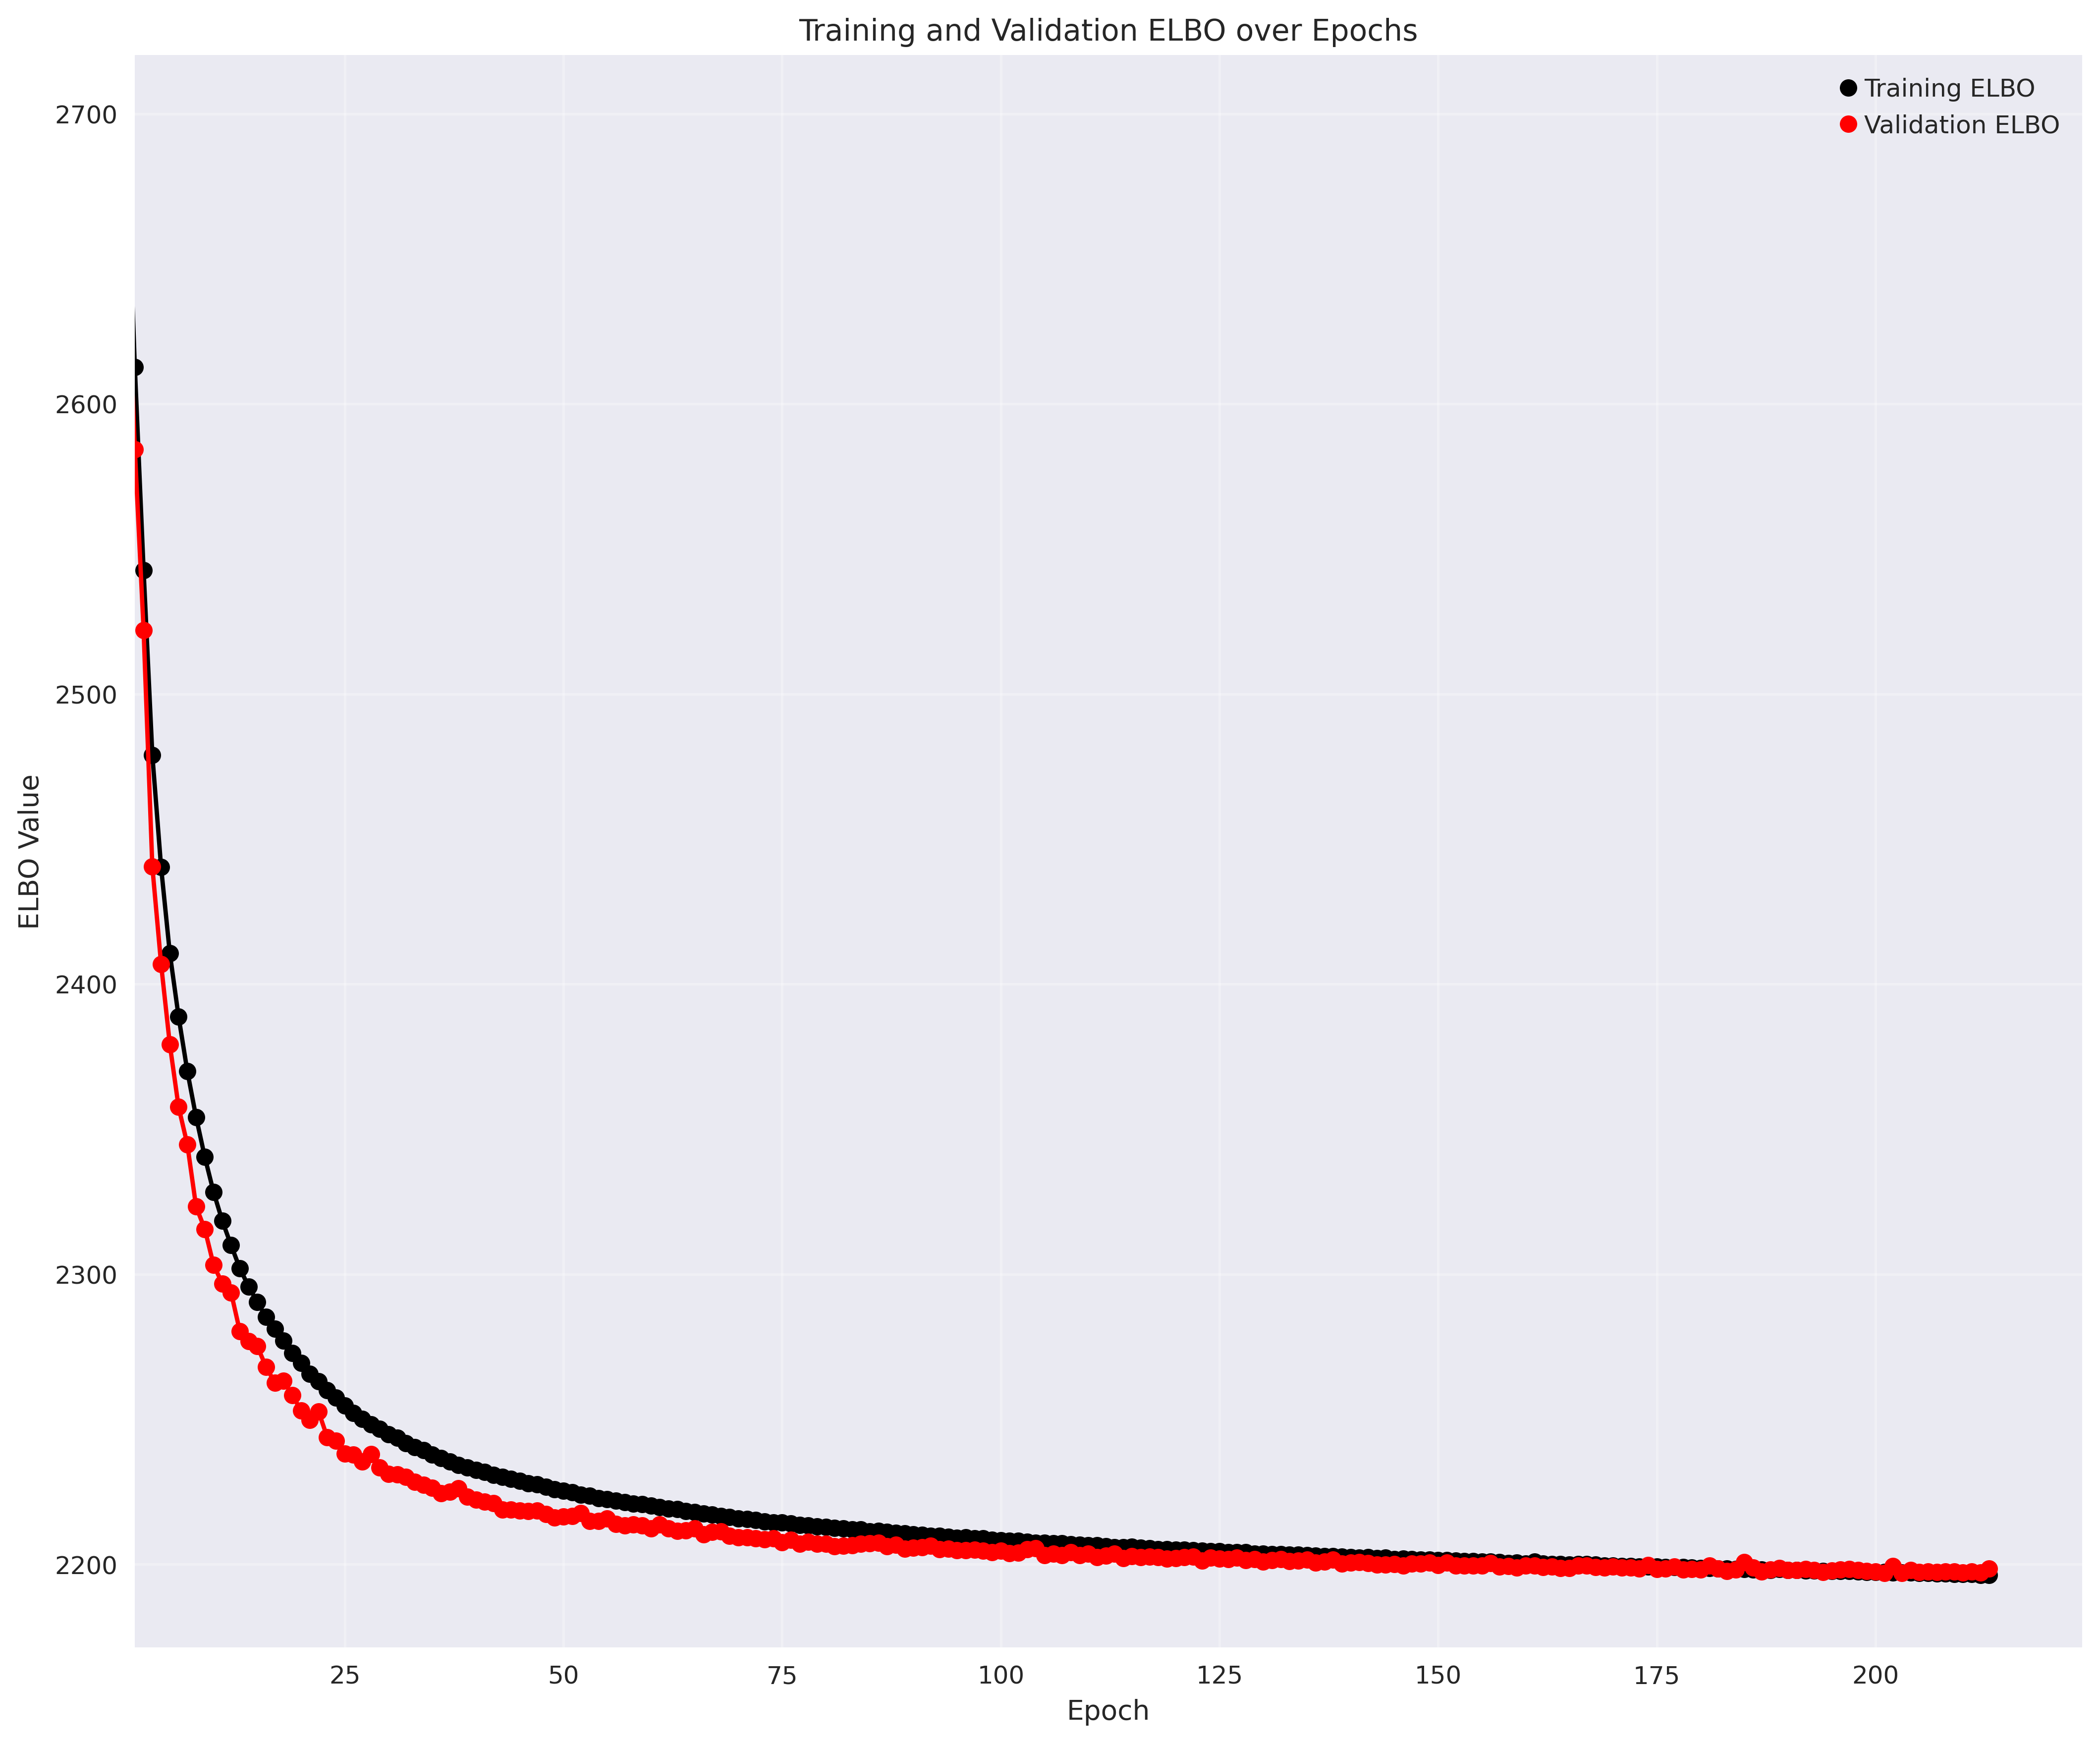

In [53]:
plt.style.use('seaborn')
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

#plt.savefig(f'integration_of_remapped_dataepithelial_scvi_model_{timestamp}/scvi_cell_types_elbo.png', dpi=300, bbox_inches='tight')

#### Label transfer with `scANVI` 

In [54]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(scvi_model, 'Unknown')

In [55]:
scanvi_model.train(300, 
                     early_stopping = True,
                   check_val_every_n_epoch = 1, 
                   enable_progress_bar = True,
                   accelerator = "gpu",
                   devices = [1])

INFO     Training for 300 epochs.                                                                                  


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/300 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


In [56]:
adata.obs["cellstates_scANVI"] = scanvi_model.predict(adata)

- Extract latent representation

In [57]:
adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation(adata)

### Explore model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [58]:
history_df = (
    scanvi_model.history['elbo_train'].astype(float)
    .join(scanvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars = ['epoch'])
)

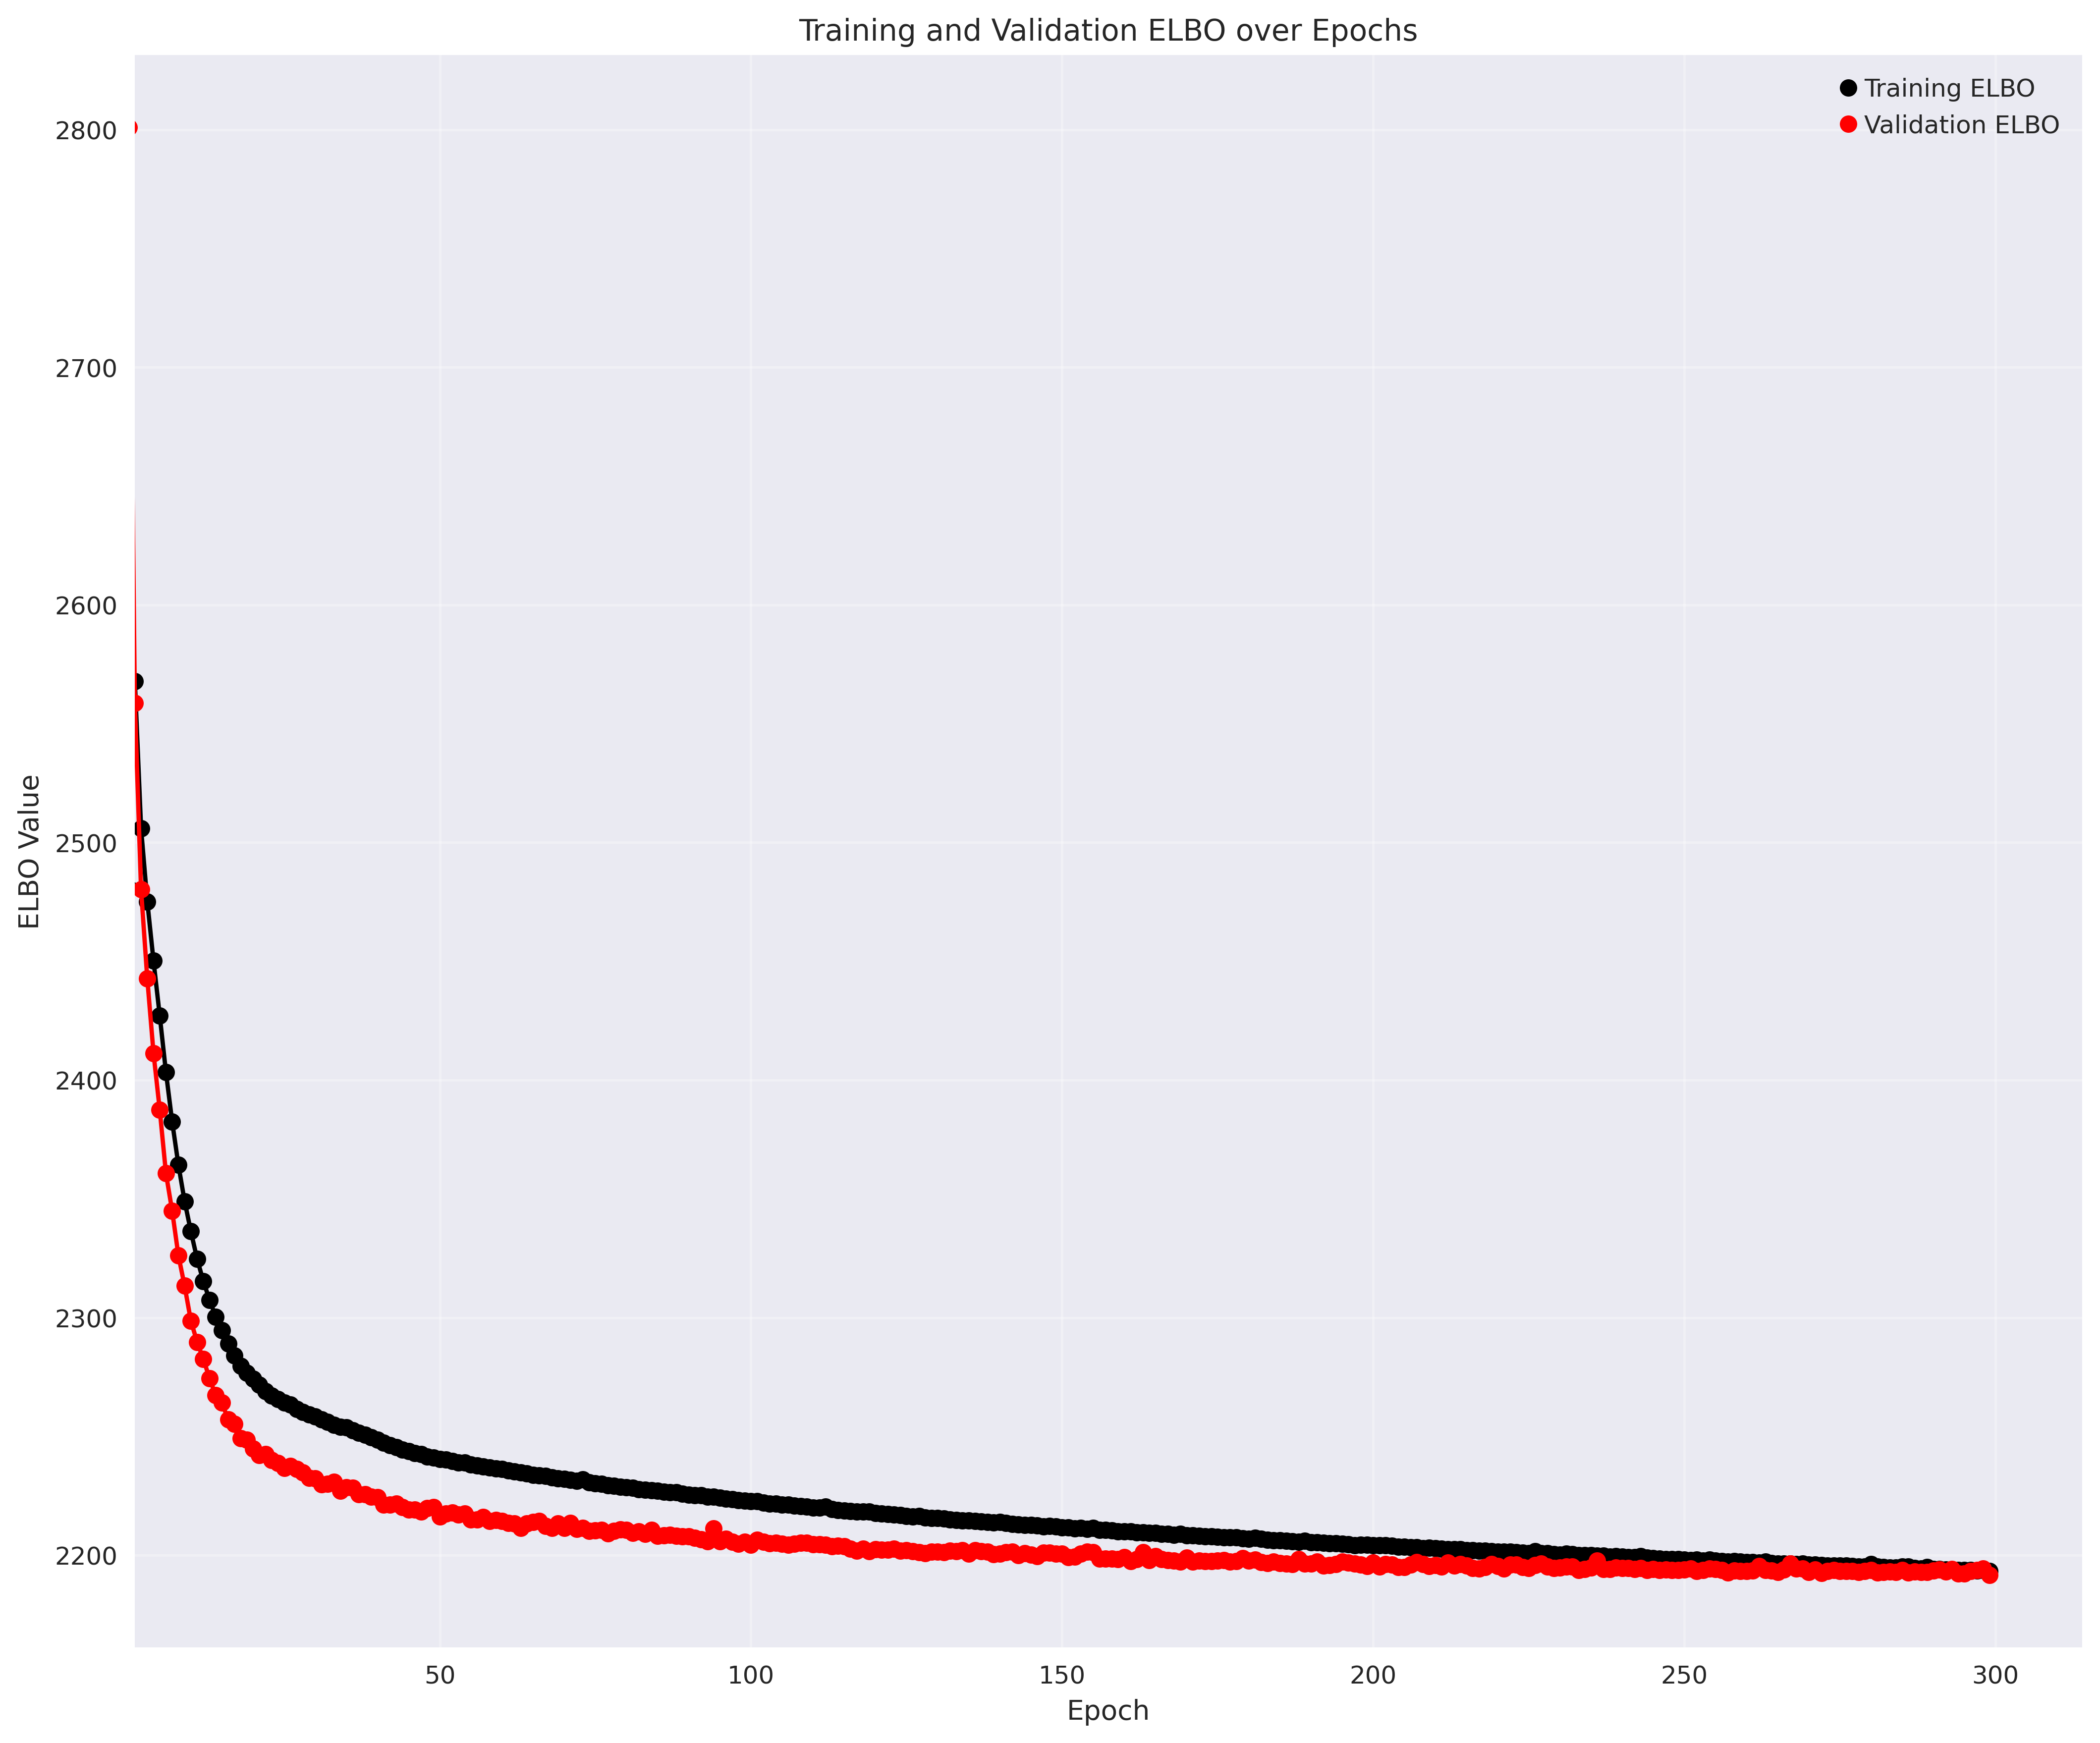

In [59]:
plt.style.use('seaborn')
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

#plt.savefig(f'integration_of_remapped_dataepithelial_scanvi_model_{timestamp}/scanvi_cell_types_elbo.png', dpi=300, bbox_inches='tight')

In [60]:
posterior_probs = scanvi_model.predict(adata, soft=True)

In [61]:
confidence_scores = posterior_probs.max(axis=1)

In [62]:
adata.obs['confidence_score'] = confidence_scores

+ Visualize dataset

In [63]:
sc.pp.neighbors(adata, use_rep = "X_scANVI", n_neighbors = 150, metric = 'minkowski')
sc.tl.umap(adata, min_dist = 0.6, spread = 8, random_state = 1712)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:02:07)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:09)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=["cellstates_scANVI", "confidence_score", 'cell_states', 'Integrated_05'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_scANVI_values_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=["Study_name", "ArrayExpress_ID", 'metadata_cluster', 'age_group'], ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['organism_part', 'developmental_stage', 'library_preparation_protocol', 'immunophenotype'], ncols=2, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_categorical_values2_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['sex', 'Cell_cycle_phase', 'developmental_stage', 'full_age', 'growth_condition'], ncols=3, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_categorical_values3_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['sampling_site', 'Material Type', 'donor_id'], ncols=3, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_categorical_values4_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=3, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_categorical_values5_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_continious_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_continious2_values_{timestamp}.png", bbox_inches="tight")
    plt.show()

## Save prepared dataset

In [72]:
adata_export= adata_raw.copy()
adata_export

AnnData object with n_obs × n_vars = 96699 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoco

In [73]:
adata_export.obs['cellstates_scANVI'] = adata.obs['cellstates_scANVI'].copy()
adata_export.obs['confidence_score'] = adata.obs['confidence_score'].copy()
adata_export.obsm['X_scVI'] = adata.obsm['X_scVI'].copy()
adata_export.obsm['X_scANVI'] = adata.obsm['X_scANVI'].copy()
adata_export.obsm['X_pca'] = adata.obsm['X_pca'].copy()
adata_export.obsm['umap_uncorrected'] = adata.obsm['umap_uncorrected'].copy()
adata_export.obsm['X_umap'] = adata.obsm['X_umap'].copy()

In [75]:
current_history = adata_export.uns['processing_history'].tolist()

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Extracted 7000 HVGs from only reference dataset with batch donor_id, deleted organoid data, concatenated small EECs substates into one group, predicted epithelial cell states using scVI-scANVI, scvi params: batch = sample_id, library_construnction_and_layout,Performer and Protocol REF, n_latent = 150, n_hidden = 256, n_layers = 3, dropout_rate = 0.1, dispersion = gene-cell, gene_likelihood = nb, 20 epochs, scanvi params: 300 epochs',
})
current_history.append(new_entry)

adata_export.uns['processing_history'] = current_history

In [76]:
project = 'gut'
species = 'hs'
name = 'AM'
counts = 'raw'
atribute = 'all_datasets_scVI_scANVI_epithelial_cellstates'

adata_export.write_h5ad(f"integration_of_remapped_data/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

In [77]:
adata.obs["cellstates_scANVI"].value_counts()

cellstates_scANVI
Enterocyte             24979
Proximal progenitor    17798
TA                     11888
Paneth                  8769
Colonocyte              8453
Stem cells              7860
BEST4+ epithelial       4926
Goblet cell             4663
Distal progenitor       4562
EEC                     2801
Name: count, dtype: int64